
# Security and Privacy (CC2009) - 25/26
## ASSIGNMENT #1: Performance Benchmarking of Cryptographic Mechanisms
### PL1 - Elements: Amanda Lucas (202400455), Aly Filho (202401045) e Silvia Pinto (202405988)


#### B. Encrypt and decrypt random files with AES in Counter Mode, using the code that you wrote previously:
##### First thing is to define 2 functions, in Python, one to encrypt and another one to decrypt, using the cryptography library from python: We will use Cipher to define a cipher with AES algorithms from algorithms in CTR mode from modes

In [12]:
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes

##### So, we define 2 generics functions using AES e CTR por encrypt and decrypt, where function 1 receives m (plaintext), the key and nonce and returns c (ciphertext), and function 2 receives c (ciphertext), the key and nonce and return the original text m (plaintext):


In [13]:
def my_encrypt_aes_ctr(plaintext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 

    encrypt = cypher.encryptor()  
    
    return encrypt.update(plaintext) + encrypt.finalize() 

def my_decrypt_aes_ctr(ciphertext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 

    decrypt = cypher.decryptor()

    return decrypt.update(ciphertext) + decrypt.finalize()

##### Now that we have the encrypt and decrypt functions, let's use this, in a simple test, we gonna import urandom from os library from python to generate random data, key and nonce, we will use hexlify to transforme this random data more visible, for mesure the time we will import timeit library from python:

In [14]:
from os import urandom
from binascii import hexlify
import timeit

In [15]:
data = urandom(8) #Create a 8 bytes random text
key = urandom(32) #Create a 32 bytes (256 bits) random key
nonce = urandom(16) #Create a 16 bytes (126 bits) random key

print(f"Random plaintext (m): {hexlify(data)}\nRandom key (k): {hexlify(key)}\nRandom nonce (n):({hexlify(nonce)}")

Random plaintext (m): b'e46b1d6fedb8f29d'
Random key (k): b'94187b9e42300bcc8c2b0d7168427a080519face9d461acf2b699e50bc91888a'
Random nonce (n):(b'7d8478b765fcce482bda7d953be4c789'


##### With the plaintext (m), the key (k), and the nonce (n), let's encrypt and check the time to do this, 1 time, then 1000 times:

In [16]:
c = my_encrypt_aes_ctr(data,key,nonce)
print(f"Ciphertext: {hexlify(c)}")


time_one = timeit.timeit(lambda: my_encrypt_aes_ctr(data, key, nonce), number=1)
print(f"Time of 1 execution: {time_one:.8f} seconds")

time_thousand = timeit.timeit(lambda: my_encrypt_aes_ctr(data, key, nonce), number=1000)
print(f"Time of 1000 executions: {time_thousand:.4f} seconds")


Ciphertext: b'a1be5b3d6f9b6d61'
Time of 1 execution: 0.00008841 seconds
Time of 1000 executions: 0.0088 seconds


##### Now that we have the Ciphertext (c), let's decrypt and check the time to do this 1 time, then 1000 times:

In [17]:
m = my_decrypt_aes_ctr(c,key,nonce)
print(f"Result from decrypt: {hexlify(c)}") 
print(data == m)

time_one = timeit.timeit(lambda: my_decrypt_aes_ctr(c, key, nonce), number=1)
print(f"Time of 1 execution: {time_one:.8f} seconds")

time_thousand = timeit.timeit(lambda: my_decrypt_aes_ctr(c, key, nonce), number=1000)
print(f"Time of 1000 executions: {time_thousand:.4f} seconds")



Result from decrypt: b'a1be5b3d6f9b6d61'
True
Time of 1 execution: 0.00006338 seconds
Time of 1000 executions: 0.0150 seconds


##### From this we can conclude, the encrypt and decrypt are working (data == m return true), the time of 1000 iterations its nearby, but not exactly, proportional to 1 time. If we do this, several times, but if the sabe data, key and nonce, we get not equal, but close, times of executions. By now, let's extrapolate the tests and get some analises and graphics about it, For turn this more visual, we gonna use numpy and matplotlib which are libraries from python to plot:

In [18]:
import numpy as np
import matplotlib.pyplot as plt

##### It was suggesting to do several analises in different data sizes of the plaintext, we gonna do it with 8, 64, 512, 4096, 32768, 262144 and 2097152 bytes sizes, for better results and avoid the bias that 1 execution can have, let's use 1000 iterations:

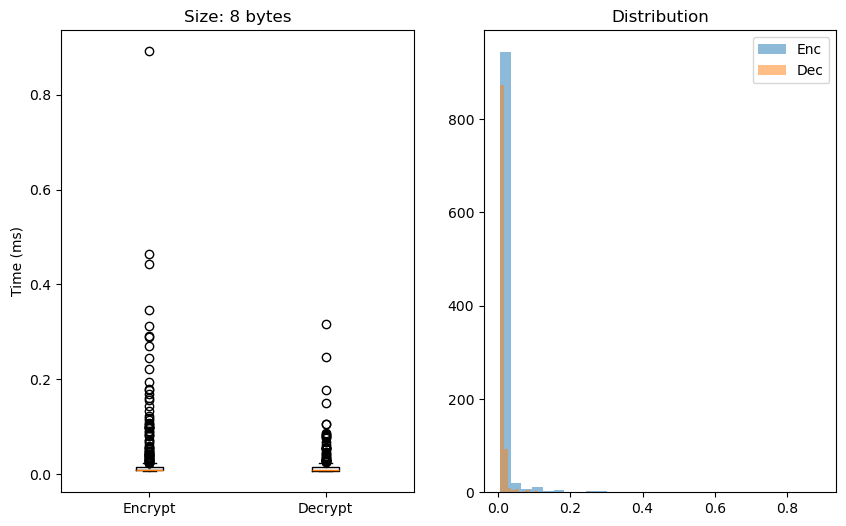

Size 8 bytes | Encrypt mean: 0.018073ms | Standard Deviation: 0.044855ms


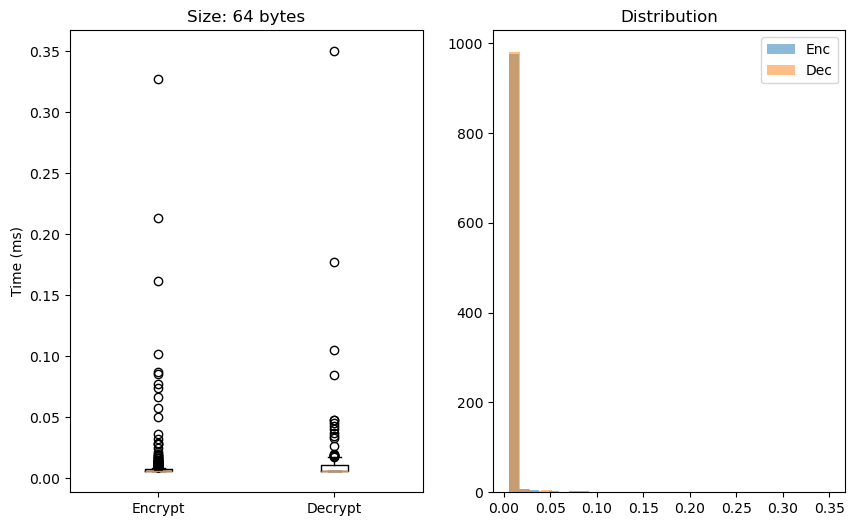

Size 64 bytes | Encrypt mean: 0.008503ms | Standard Deviation: 0.014595ms


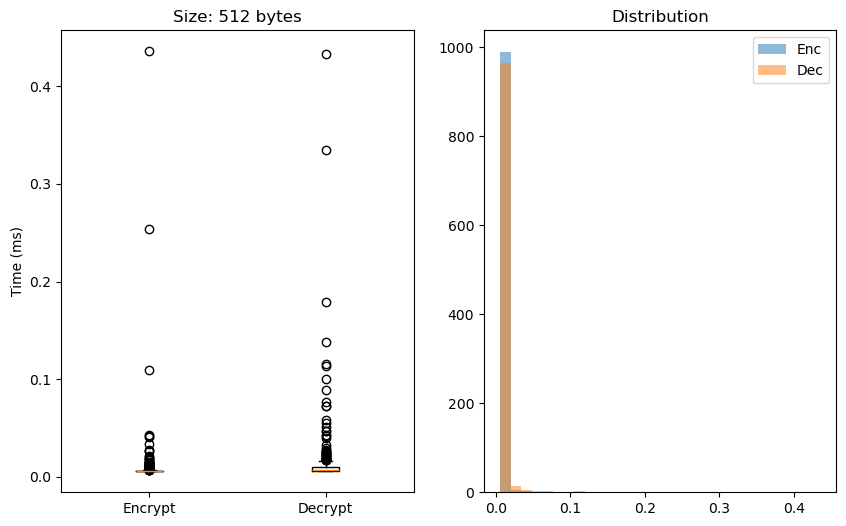

Size 512 bytes | Encrypt mean: 0.008165ms | Standard Deviation: 0.016247ms


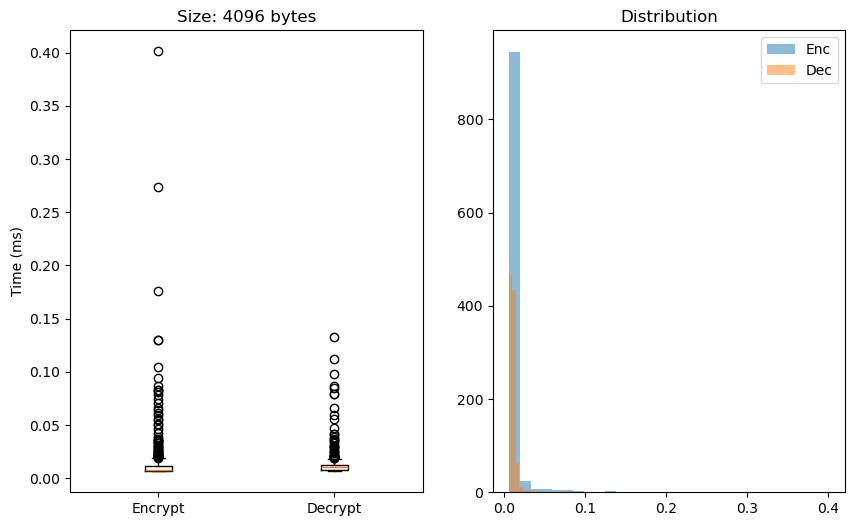

Size 4096 bytes | Encrypt mean: 0.011751ms | Standard Deviation: 0.019124ms


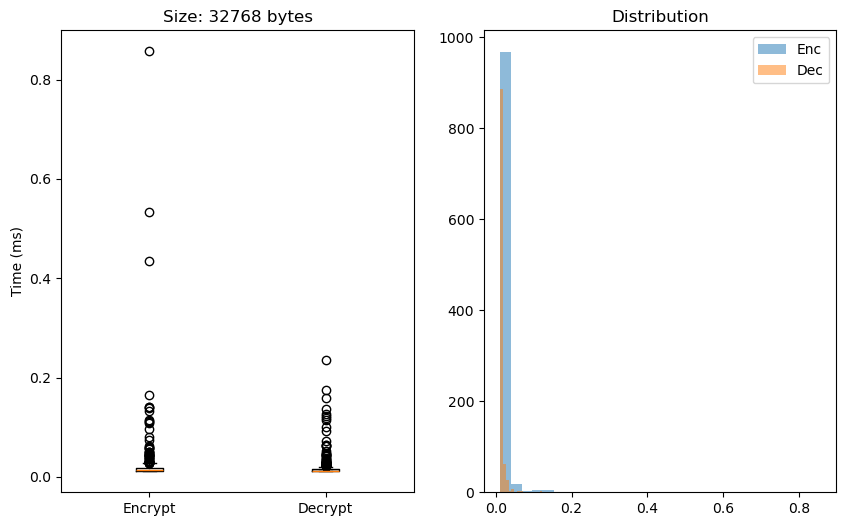

Size 32768 bytes | Encrypt mean: 0.019185ms | Standard Deviation: 0.036193ms


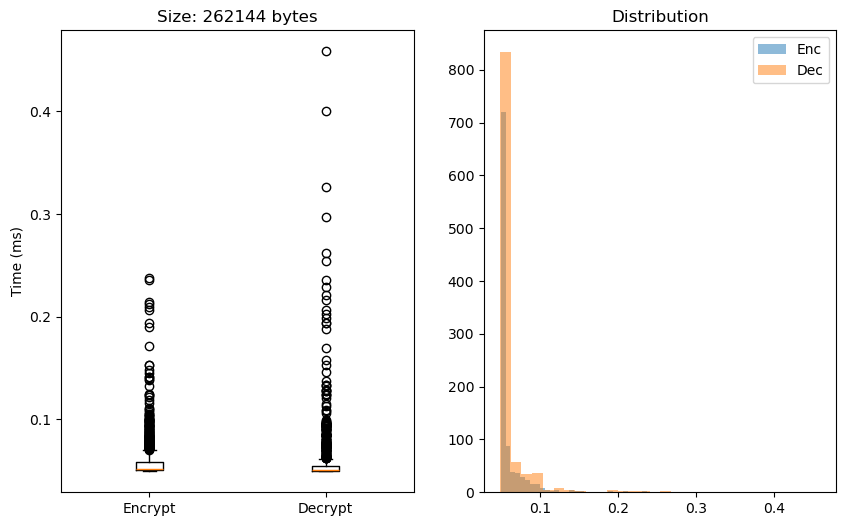

Size 262144 bytes | Encrypt mean: 0.059305ms | Standard Deviation: 0.020802ms


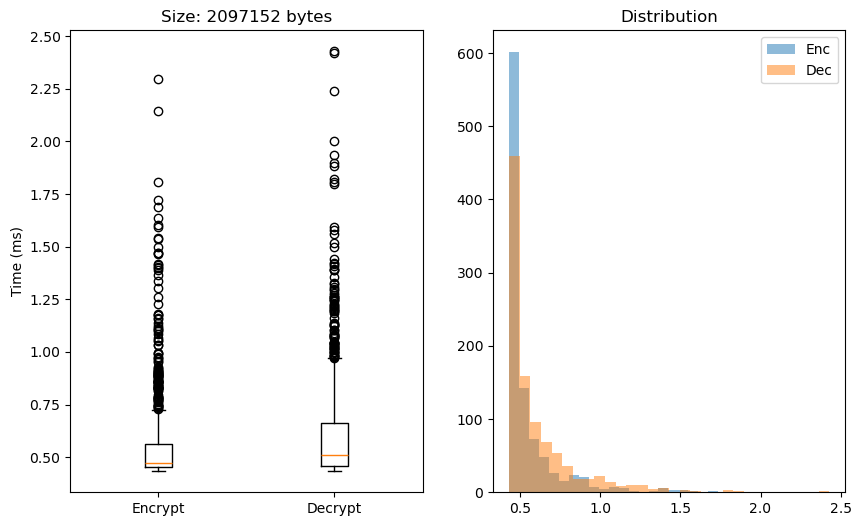

Size 2097152 bytes | Encrypt mean: 0.557065ms | Standard Deviation: 0.209759ms


In [19]:
sizes = [8, 64, 512, 4096, 32768, 262144, 2097152]
iterations = 1000

all_results = {}

key = urandom(32)

for size in sizes:
    data = urandom(size)
    nonce = urandom(16)

    enc_times = np.array(timeit.repeat(
        stmt=lambda: my_encrypt_aes_ctr(data, key,nonce),
        repeat=iterations,
        number=1
    ))* 1000 #convert to ms

    c = my_encrypt_aes_ctr(data,key,nonce)
    dec_times = np.array(timeit.repeat(
        stmt = lambda: my_decrypt_aes_ctr(c,key,nonce),
        repeat=iterations,
        number=1
    ))*1000 #convert to ms

    all_results[size] = {'enc': enc_times, 'dec': dec_times}

    #Plot por Individual analysis by size
    plt.figure(figsize=(10,6))
    plt.subplot(1 ,2 ,1)
    plt.boxplot([enc_times,dec_times], tick_labels=['Encrypt', 'Decrypt'])
    plt.title(f'Size: {size} bytes')
    plt.ylabel('Time (ms)')

    plt.subplot(1 ,2 ,2)
    plt.hist(enc_times, bins=30,alpha=0.5, label='Enc')
    plt.hist(dec_times, bins=30, alpha=0.5, label ='Dec')
    plt.title('Distribution')
    plt.legend()
    plt.show()
    print(f"Size {size} bytes | Encrypt mean: {np.mean(enc_times):.6f}ms | Standard Deviation: {np.std(enc_times):.6f}ms")


##### Outputs of this graphics:
1) *Overhead and System Jitter:* 
    - The overhead is the time, memory and extras resources that the system expends to manage one task, jitter is the system fluctuation, that is, the unwanted variation in a task that should be constant.
     - About this, in the graphics above, at the 8 bytes files the boxplot has a lot of outliers because the processing time is too small that any system movement from operational system (jitter) do the time oscile from 0 to almost 9ms, at the 2MB files it increase to 2.5ms and the boxplot "body" is more robust.
     - We can conclude that in small files we are very influence by Python and OS latency, but im bigger files we can mesure more precisely the real speed of AES algorithm.

2) *Distribution Estabilization:*:
    - In the histograms we can see that at the smallest sizes, the histogram is one continuous and fine line, that indicates that the data is processed almost in a instantaneous way, and the oscitation is irrelevant for the user, although it is statistically noise.
    - In the biggest file size the histogram starts to get a "body" and a long right tail, it suggest that the time of execution starts following a more predictable distribution, where the computacional costs of iterates in the memory blocks overcome the noisy.

3) *Symmetry between Encrypt and Decrypt:*
    - In all graphics, the box of "encrypt" and "decrypt" are visually identical in positions and sizes.
    - That confirmes one very import characteristic about the AES-CTR: is a symmetric algorithm where the operation to cipher and decipher is the sabe (XOR), and are no extra cost for revert the process.

4) *Outliers Analysis:*
    - We can see that even in the bigger size file, there are spikes of 2.5ms although the mean is 0.5ms.
    - Thats confirms the fact of if we are using a huge system, always can happen random spikes of slowness that can not be optimates in code.

##### Now that we have all of this individual datas and results, let's do a cross-size analysis with all oh them:

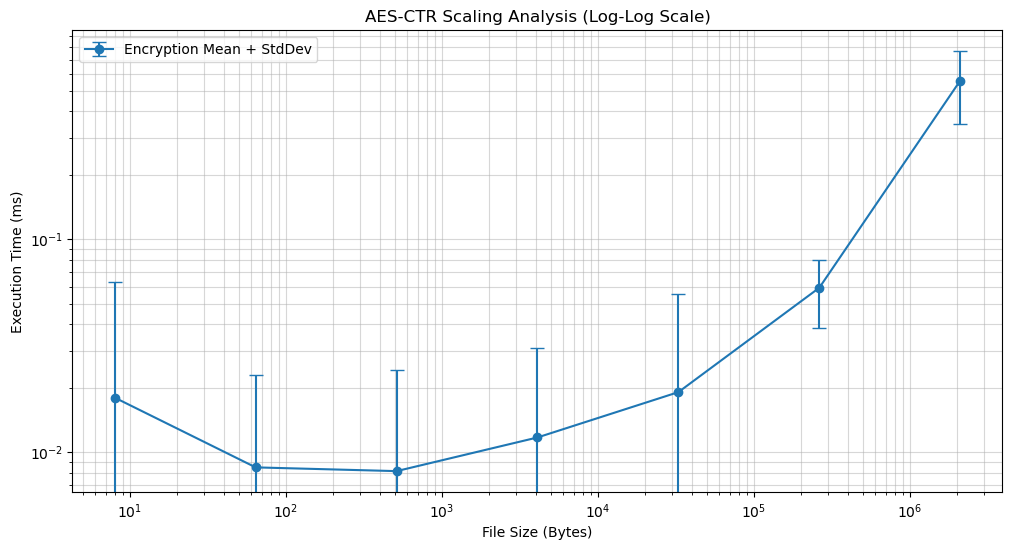

In [20]:

plt.figure(figsize=(12, 6))

mean_enc = [np.mean(all_results[s]['enc']) for s in sizes]
std_enc = [np.std(all_results[s]['enc']) for s in sizes]


plt.errorbar(sizes, mean_enc, yerr=std_enc, fmt='-o', capsize=5, label='Encryption Mean + StdDev')
plt.xscale('log')
plt.yscale('log') # Also log for Y to see the linear relationship clearly
plt.title('AES-CTR Scaling Analysis (Log-Log Scale)')
plt.xlabel('File Size (Bytes)')
plt.ylabel('Execution Time (ms)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

##### For better visualization, we used this is a log-log graphic, where both axes X an Y uses logarithm scale. We can conclude:
1) *Dominance zone of Overhead:* From 10^1 to 10^^3 the execution time doesn't change a lot, here the overhead od python and operational system is bigger then the time of encrypt and decrypt, we are almost measuring the "bureaucracy" os system and not really the AES.

2) *Inflection point:* Over the 4KB file the line starts to get up in a constant and inclined way, in this size the graphic become a straight line em log scale, that proofs that que complexity of AES-CTR algorithm is O(n). So by now if you double the size of file, the time of execution will proportionally double too.

3) *Variability:* The horizontal bars represents the standard deviation, in the begging of graphic they are very big, thats confirmes that System jitter affects a lot in this size of files, then in the final of graphics it seens long but in logarithm scale, the plot shows that the performance became a lot of predictable and stable.

##### Conclusion of B:
1) *The results changes with the same file are run multiples times?* Yes, but its not because of algorithm, AES its a deterministic algorithm, and the standard deviation occurs by the System Jitter. In small files, like * bytes, the cost to call the python function is bigger than the cost of encrypt by itself.

2) *The results changes in multiples files with the same size?* In AES-CTR the content of file doesn't affect the execution time, so if occurs an variation, its random spikes of noises of system and its statistically insignificant.
